# Modeling
Train Logistic Regression, Random Forest, and XGBoost.
Tune decision threshold to meet business constraint:
reduce defaults by 30%, reject at most 10% more good borrowers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve
)
import warnings
warnings.filterwarnings("ignore")

# Load preprocessed data
X_train = pd.read_parquet("../data/X_train.parquet")
X_test  = pd.read_parquet("../data/X_test.parquet")
y_train = pd.read_parquet("../data/y_train.parquet").squeeze()
y_test  = pd.read_parquet("../data/y_test.parquet").squeeze()

# int_rate added back: tree models handle multicollinearity better than linear models
# installment and total_acc still dropped (redundant with loan_amnt and open_acc)
DROP_COLS = ["installment", "total_acc"]
X_train = X_train.drop(columns=DROP_COLS)
X_test  = X_test.drop(columns=DROP_COLS)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Features used:", list(X_train.columns))

X_train shape: (1078447, 34)
X_test shape:  (269612, 34)
Features used: ['dti', 'annual_inc', 'loan_amnt', 'int_rate', 'grade', 'emp_length', 'open_acc', 'revol_bal', 'revol_util', 'mort_acc', 'delinq_2yrs', 'inq_last_6mths', 'credit_history_years', 'has_derogatory', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified']


## Helper: Evaluation Function
Reusable function to evaluate any model consistently.

In [2]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= threshold).astype(int)

    auc   = roc_auc_score(y_test, proba)
    cm    = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    default_catch_rate = tp / (tp + fn)   # recall for defaults
    good_rejection_rate = fp / (tn + fp)  # % good borrowers incorrectly rejected

    print(f'\n=== {name} (threshold={threshold}) ===')
    print(f'ROC-AUC:              {auc:.4f}')
    print(f'Default Catch Rate:   {default_catch_rate:.2%}  (recall for class 1)')
    print(f'Good Rejection Rate:  {good_rejection_rate:.2%}  (false positive rate)')
    print(f'Confusion Matrix:')
    print(f'  TN={tn:,}  FP={fp:,}')
    print(f'  FN={fn:,}  TP={tp:,}')
    print()
    print(classification_report(y_test, preds, target_names=['Fully Paid', 'Default']))
    return proba, auc

## Model 1: Logistic Regression (Baseline)

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
lr_proba, lr_auc = evaluate_model('Logistic Regression', lr, X_test, y_test)


=== Logistic Regression (threshold=0.5) ===
ROC-AUC:              0.6996
Default Catch Rate:   6.51%  (recall for class 1)
Good Rejection Rate:  1.62%  (false positive rate)
Confusion Matrix:
  TN=212,248  FP=3,500
  FN=50,356  TP=3,508

              precision    recall  f1-score   support

  Fully Paid       0.81      0.98      0.89    215748
     Default       0.50      0.07      0.12     53864

    accuracy                           0.80    269612
   macro avg       0.65      0.52      0.50    269612
weighted avg       0.75      0.80      0.73    269612



## Model 2: Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba, rf_auc = evaluate_model('Random Forest', rf, X_test, y_test)


=== Random Forest (threshold=0.5) ===
ROC-AUC:              0.7072
Default Catch Rate:   67.88%  (recall for class 1)
Good Rejection Rate:  37.89%  (false positive rate)
Confusion Matrix:
  TN=134,004  FP=81,744
  FN=17,299  TP=36,565

              precision    recall  f1-score   support

  Fully Paid       0.89      0.62      0.73    215748
     Default       0.31      0.68      0.42     53864

    accuracy                           0.63    269612
   macro avg       0.60      0.65      0.58    269612
weighted avg       0.77      0.63      0.67    269612



## Model 3: XGBoost

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_proba, xgb_auc = evaluate_model('XGBoost', xgb, X_test, y_test)


=== XGBoost (threshold=0.5) ===
ROC-AUC:              0.7170
Default Catch Rate:   67.69%  (recall for class 1)
Good Rejection Rate:  36.10%  (false positive rate)
Confusion Matrix:
  TN=137,853  FP=77,895
  FN=17,404  TP=36,460

              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0.74    215748
     Default       0.32      0.68      0.43     53864

    accuracy                           0.65    269612
   macro avg       0.60      0.66      0.59    269612
weighted avg       0.77      0.65      0.68    269612



## ROC Curve Comparison

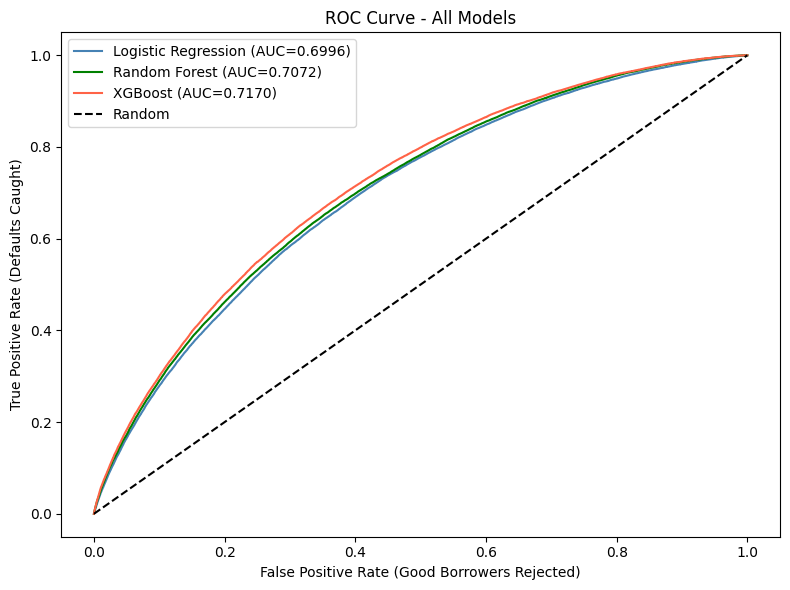

In [6]:
plt.figure(figsize=(8, 6))
for name, proba, color in [
    ('Logistic Regression', lr_proba, 'steelblue'),
    ('Random Forest',       rf_proba, 'green'),
    ('XGBoost',             xgb_proba,'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color)

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate (Good Borrowers Rejected)')
plt.ylabel('True Positive Rate (Defaults Caught)')
plt.title('ROC Curve - All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=100)
plt.show()

## Threshold Tuning for Business Constraint
**Goal:** Catch at least 30% more defaults, reject at most 10% more good borrowers.
We tune the decision threshold on the best model (XGBoost).

In [7]:
# Baseline at default threshold 0.5
base_preds = (xgb_proba >= 0.5).astype(int)
cm_base = confusion_matrix(y_test, base_preds)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
base_catch = tp_b / (tp_b + fn_b)
base_good_reject = fp_b / (tn_b + fp_b)
print(f'Baseline (t=0.5): catch={base_catch:.2%}, good_rejected={base_good_reject:.2%}')

# Target: catch >= base + 30%, good_rejected <= base_good_reject + 10%
target_catch = base_catch * 1.30
max_good_reject = base_good_reject + 0.10
print(f'Target catch rate:      >= {target_catch:.2%}')
print(f'Max good rejection:     <= {max_good_reject:.2%}')

# Sweep thresholds
results = []
for t in np.arange(0.1, 0.9, 0.01):
    preds = (xgb_proba >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    catch = tp / (tp + fn)
    good_rej = fp / (tn + fp)
    results.append({'threshold': round(t, 2), 'catch_rate': catch, 'good_rejection': good_rej})

thresh_df = pd.DataFrame(results)

# Find thresholds meeting the business constraint
valid = thresh_df[
    (thresh_df['catch_rate'] >= target_catch) &
    (thresh_df['good_rejection'] <= max_good_reject)
].copy()

print(f'\nThresholds meeting business constraint:')
if len(valid) > 0:
    print(valid.to_string(index=False))
    best_t = valid.sort_values('good_rejection').iloc[0]['threshold']
    print(f'\nBest threshold: {best_t}')
else:
    print('No threshold meets both constraints exactly.')
    print('\nClosest options:')
    thresh_df['score'] = thresh_df['catch_rate'] - thresh_df['good_rejection']
    print(thresh_df.sort_values('score', ascending=False).head(5).to_string(index=False))

Baseline (t=0.5): catch=67.69%, good_rejected=36.10%
Target catch rate:      >= 88.00%
Max good rejection:     <= 46.10%

Thresholds meeting business constraint:
No threshold meets both constraints exactly.

Closest options:
 threshold  catch_rate  good_rejection    score
      0.50    0.676890        0.361046 0.315844
      0.49    0.694304        0.379146 0.315158
      0.48    0.711904        0.397093 0.314811
      0.51    0.657879        0.343266 0.314613
      0.52    0.639240        0.325658 0.313582


## Final Model Evaluation at Optimal Threshold

Evaluating XGBoost at threshold = 0.4

=== XGBoost (tuned threshold) (threshold=0.4) ===
ROC-AUC:              0.7170
Default Catch Rate:   83.00%  (recall for class 1)
Good Rejection Rate:  54.43%  (false positive rate)
Confusion Matrix:
  TN=98,316  FP=117,432
  FN=9,157  TP=44,707

              precision    recall  f1-score   support

  Fully Paid       0.91      0.46      0.61    215748
     Default       0.28      0.83      0.41     53864

    accuracy                           0.53    269612
   macro avg       0.60      0.64      0.51    269612
weighted avg       0.79      0.53      0.57    269612



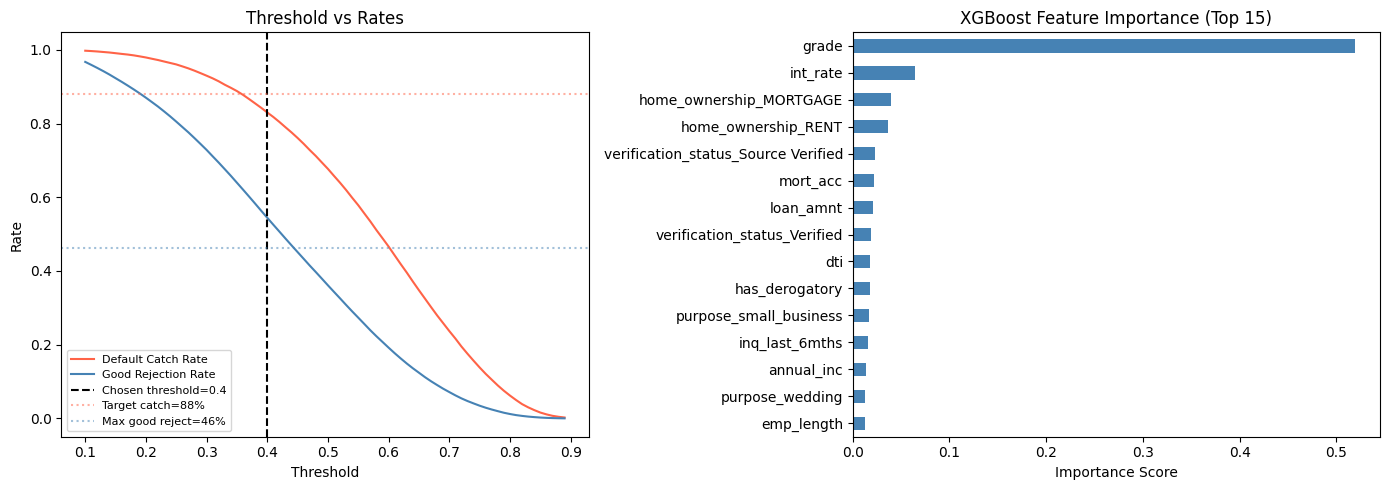

In [8]:
# Use best threshold found above (or manually set if none found)
try:
    final_threshold = best_t
except NameError:
    final_threshold = 0.4  # fallback

print(f'Evaluating XGBoost at threshold = {final_threshold}')
_, _ = evaluate_model('XGBoost (tuned threshold)', xgb, X_test, y_test, threshold=final_threshold)

# Threshold vs metrics plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['catch_rate'], color='tomato', label='Default Catch Rate')
axes[0].plot(thresh_df['threshold'], thresh_df['good_rejection'], color='steelblue', label='Good Rejection Rate')
axes[0].axvline(final_threshold, color='black', linestyle='--', label=f'Chosen threshold={final_threshold}')
axes[0].axhline(target_catch, color='tomato', linestyle=':', alpha=0.5, label=f'Target catch={target_catch:.0%}')
axes[0].axhline(max_good_reject, color='steelblue', linestyle=':', alpha=0.5, label=f'Max good reject={max_good_reject:.0%}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Rate')
axes[0].set_title('Threshold vs Rates')
axes[0].legend(fontsize=8)

# Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=True).tail(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('XGBoost Feature Importance (Top 15)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/threshold_tuning.png', dpi=100)
plt.show()

## Save Final Model

## Optimal Threshold: F2-Score Optimization

In credit risk, **missing a default is more costly than rejecting a good borrower**.
F2-score weights recall 2x more than precision — finding the threshold that
best balances catching defaults while controlling good borrower rejections.

Best F2 threshold: 0.35
Best F2 score:     0.5962
=== XGBoost at F2-Optimal Threshold (0.35) ===
ROC-AUC:                    0.7170
Default Catch Rate:         88.80%
Good Borrower Rejection:    63.94%
Confusion Matrix:
  TN=77,800  FP=137,948
  FN=6,034  TP=47,830

--- Business Impact ---
Loans approved:             83,834
Defaults caught & rejected: 47,830
Defaults missed (slipped):  6,034
Default rate among approved:7.20%  (was 19.98% without model)
Default rate reduction:     64.0%

              precision    recall  f1-score   support

  Fully Paid       0.93      0.36      0.52    215748
     Default       0.26      0.89      0.40     53864

    accuracy                           0.47    269612
   macro avg       0.59      0.62      0.46    269612
weighted avg       0.79      0.47      0.50    269612



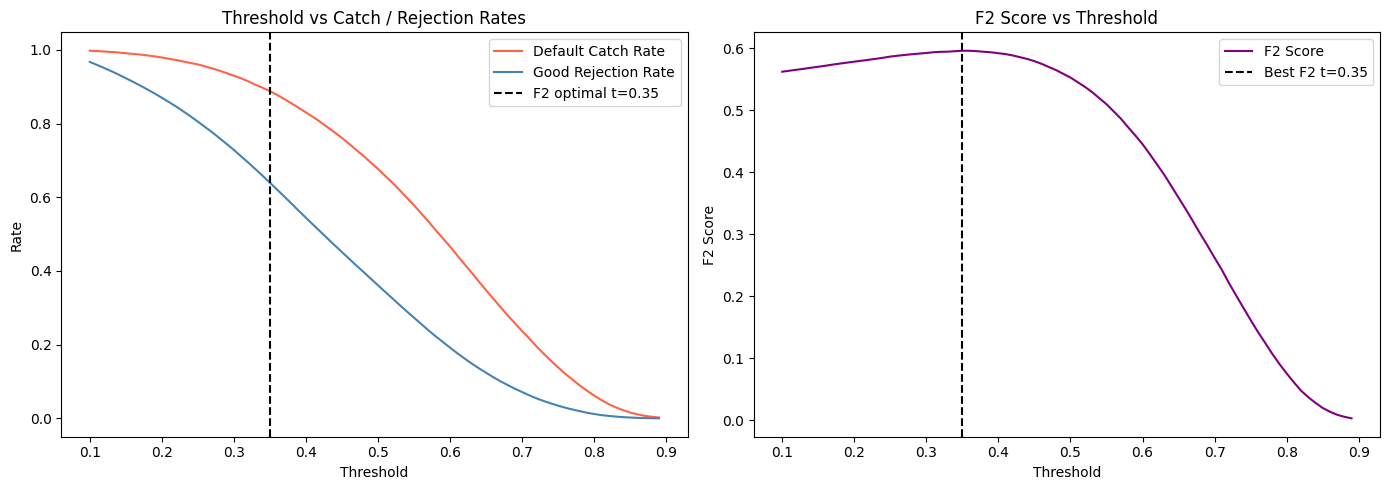

In [10]:
from sklearn.metrics import fbeta_score, precision_recall_curve

# Compute F2 score across all thresholds
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, xgb_proba)

f2_scores = []
for p, r in zip(precisions, recalls):
    if (4 * p + r) > 0:
        f2 = (5 * p * r) / (4 * p + r)
    else:
        f2 = 0
    f2_scores.append(f2)

best_idx = np.argmax(f2_scores)
best_f2_threshold = round(float(thresholds_pr[best_idx]), 2)
best_f2 = f2_scores[best_idx]

print(f"Best F2 threshold: {best_f2_threshold}")
print(f"Best F2 score:     {best_f2:.4f}")

# Evaluate at F2-optimal threshold
preds_f2 = (xgb_proba >= best_f2_threshold).astype(int)
cm_f2 = confusion_matrix(y_test, preds_f2)
tn_f2, fp_f2, fn_f2, tp_f2 = cm_f2.ravel()

catch_f2     = tp_f2 / (tp_f2 + fn_f2)
good_rej_f2  = fp_f2 / (tn_f2 + fp_f2)
default_rate_approved = fn_f2 / (tn_f2 + fn_f2)  # default rate among approved loans
baseline_default_rate = (tp_f2 + fn_f2) / len(y_test)

print(f"=== XGBoost at F2-Optimal Threshold ({best_f2_threshold}) ===")
print(f"ROC-AUC:                    {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"Default Catch Rate:         {catch_f2:.2%}")
print(f"Good Borrower Rejection:    {good_rej_f2:.2%}")
print(f"Confusion Matrix:")
print(f"  TN={tn_f2:,}  FP={fp_f2:,}")
print(f"  FN={fn_f2:,}  TP={tp_f2:,}")
print()
print("--- Business Impact ---")
print(f"Loans approved:             {tn_f2 + fn_f2:,}")
print(f"Defaults caught & rejected: {tp_f2:,}")
print(f"Defaults missed (slipped):  {fn_f2:,}")
print(f"Default rate among approved:{default_rate_approved:.2%}  (was {baseline_default_rate:.2%} without model)")
print(f"Default rate reduction:     {(baseline_default_rate - default_rate_approved)/baseline_default_rate:.1%}")
print()
print(classification_report(y_test, preds_f2, target_names=["Fully Paid", "Default"]))

# Threshold sweep plot
sweep = []
for t in np.arange(0.1, 0.9, 0.01):
    p = (xgb_proba >= t).astype(int)
    cm = confusion_matrix(y_test, p)
    tn, fp, fn, tp = cm.ravel()
    catch = tp / (tp + fn)
    gr = fp / (tn + fp)
    f2 = fbeta_score(y_test, p, beta=2)
    sweep.append({"threshold": round(t,2), "catch": catch, "good_reject": gr, "f2": f2})
sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sweep_df["threshold"], sweep_df["catch"], color="tomato", label="Default Catch Rate")
axes[0].plot(sweep_df["threshold"], sweep_df["good_reject"], color="steelblue", label="Good Rejection Rate")
axes[0].axvline(best_f2_threshold, color="black", linestyle="--", label=f"F2 optimal t={best_f2_threshold}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Rate")
axes[0].set_title("Threshold vs Catch / Rejection Rates")
axes[0].legend()

axes[1].plot(sweep_df["threshold"], sweep_df["f2"], color="purple", label="F2 Score")
axes[1].axvline(best_f2_threshold, color="black", linestyle="--", label=f"Best F2 t={best_f2_threshold}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F2 Score")
axes[1].set_title("F2 Score vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/f2_threshold.png", dpi=100)
plt.show()

In [11]:
import pickle

with open("../data/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

with open("../data/threshold.txt", "w") as f:
    f.write(str(best_f2_threshold))

print("Saved: xgb_model.pkl")
print("Saved: threshold.txt ->", best_f2_threshold)
print("Dropped features (redundant):", DROP_COLS)
print("Final feature count:", X_train.shape[1])
print("Final threshold (F2-optimal):", best_f2_threshold)

Saved: xgb_model.pkl
Saved: threshold.txt -> 0.35
Dropped features (redundant): ['installment', 'total_acc']
Final feature count: 34
Final threshold (F2-optimal): 0.35
